# 02 - Bias and Fairness Analysis

**NovaCred Credit Application Governance Analysis**

This notebook documents the bias and fairness assessment of the cleaned credit
applications dataset. We systematically evaluate potential disparities in loan
approval outcomes across protected and related attributes, focusing on
**gender bias**, **age-based discrimination**, and **proxy discrimination**.

The analysis includes the computation of **fairness metrics** (such as the
Disparate Impact Ratio), **statistical significance testing**, and exploratory
analysis of **interaction effects** between demographic attributes.
The goal is to identify whether the credit approval process exhibits patterns
that may indicate unfair or discriminatory outcomes.

## 1. Imports & Load Data 

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from dateutil import parser as date_parser


df = pd.read_csv("../data/cleaned_credit_applications.csv")
df.shape, df.columns.tolist()

((500, 29),
 ['app_id',
  'full_name',
  'email',
  'ssn',
  'ip_address',
  'gender',
  'date_of_birth',
  'zip_code',
  'annual_income',
  'credit_history_months',
  'debt_to_income',
  'savings_balance',
  'spending_total',
  'spending_categories',
  'spending_category_list',
  'loan_approved',
  'interest_rate',
  'approved_amount',
  'rejection_reason',
  'processing_timestamp',
  'loan_purpose',
  'notes',
  'gender_original',
  'date_of_birth_original',
  'high_dti_flag',
  'email_valid',
  'completeness_score',
  'completeness_pct',
  'ssn_duplicate_flag'])

## 2. Outcome And Age Variable Calculation

In this section, we prepare key variables required for the bias and fairness analysis. 
Specifically, we construct the binary **loan approval outcome** used throughout the analysis 
and derive an **age variable** from the applicants' date of birth. 

To facilitate fairness assessments, applicants are additionally grouped into **age categories**, 
allowing us to evaluate potential disparities in loan approval outcomes across demographic groups. 
These variables serve as the basis for subsequent fairness metrics, statistical testing, 
and bias analysis.

### 2.1 Define Loan Approval Outcome

In [8]:
# Outcome
df["loan_approved"] = df["loan_approved"].astype(bool)

### 2.2 Compute Applicant Age

In [9]:
# Age from date_of_birth (cleaning notebook already parsed dates at some point, but CSV may store as string)
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")

today = pd.Timestamp("today").normalize()
df["age"] = ((today - df["date_of_birth"]).dt.days / 365.25).round(1)

### 2.3 Create Age Groups

In [10]:
# Age groups (feel free to tweak bins after you look at distribution)
bins = [0, 29, 44, 59, 120]
labels = ["<30", "30–44", "45–59", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

### 2.4 Age Distribution Histogram

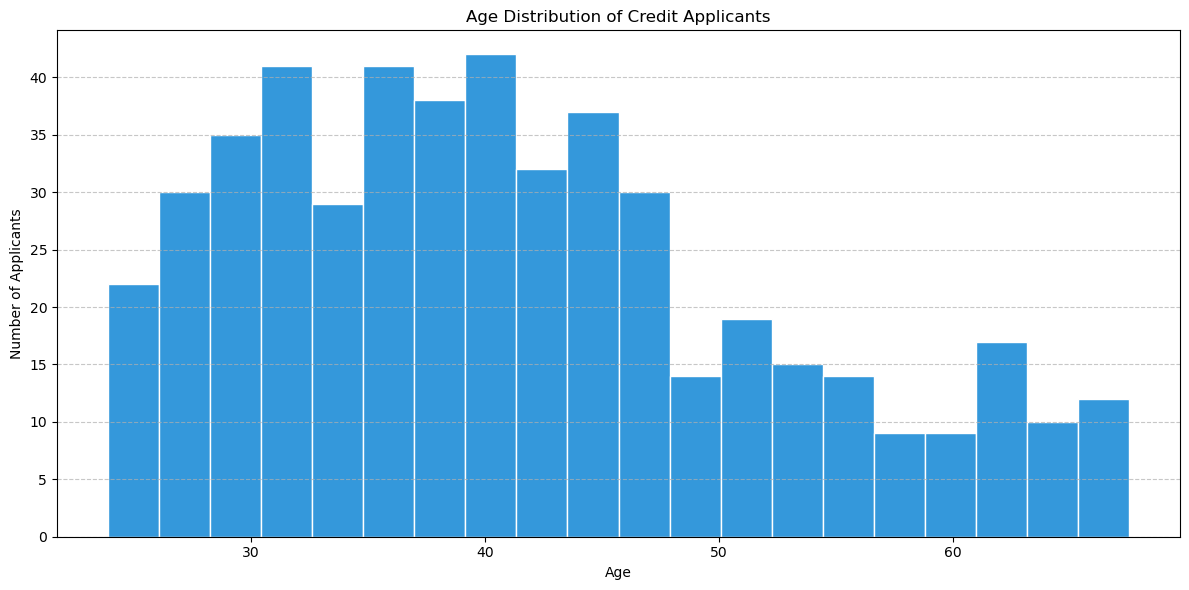

In [11]:
# Age distribution visualization (consistent style with Data Quality notebook)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df["age"], bins=20, color="#3498db", edgecolor="white")

ax.set_title("Age Distribution of Credit Applicants")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Applicants")

# add gridlines like in the data quality notebook
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## 3. Main Cohort Definition

This section defines the primary analysis cohort, which is used to analyze fairness and bias.
To guarantee methodological consistency, we restrict the dataset to applicants with a valid binary gender classification (**Male/Female**) for the baseline Disparate Impact analysis, ensuring non-missing data.**Age** values are for age-based and intersectional analysis.

To ensure transparency and reproducibility, we document cohort size and group numbers after filtering down below.

In [12]:
# Define main cohort used for the bias analysis

total_records = len(df)

# keep only applicants with binary gender (Male / Female)
gender_filter = df["gender"].isin(["Male", "Female"])
records_after_gender_filter = gender_filter.sum()

# ensure age is available for age-related analysis
age_filter = df["age"].notna()
records_after_age_filter = (gender_filter & age_filter).sum()

# create main analysis dataset
df_main = df[gender_filter & age_filter].copy()

# summary of filtering steps
cohort_summary = pd.DataFrame({
    "Step": ["Total records","After gender filter","After gender + age filter (df_main)"],
    "Records": [total_records,int(records_after_gender_filter),int(records_after_age_filter)],
    "Dropped": [0,int(total_records - records_after_gender_filter),int(records_after_gender_filter - records_after_age_filter)]
})

cohort_summary

,Step,Records,Dropped
0,Total records,500,0
1,After gender filter,498,2
2,After gender + age filter (df_main),495,3


## 4. Gender Bias: Disparate Impact + Statistical Test

Here, we examine whether the **loan approval rate** differs between gender groups.
To do this, we do two things:

1) **Disparate Impact (DI) Ratio**: Approval Rate (Female) / Approval Rate (Male) and classification according to the **Four-Fifths Rule (0.8)**
2) **Significance test**: Chi-square test on the 2×2 crosstab (gender × approval), plus **Cramér's V** as effect size

Important: These are **associations**, not causal statements.

### 4.1 Approval rates by gender

In [13]:
approval_by_gender = df_main.groupby("gender")["loan_approved"].mean().sort_index()
counts_by_gender = df_main["gender"].value_counts().sort_index()

approval_by_gender, counts_by_gender

(gender
 Female    0.506024
 Male      0.658537
 Name: loan_approved, dtype: float64,
 gender
 Female    249
 Male      246
 Name: count, dtype: int64)

### 4.2 Disparate Impact

In [14]:
privileged = "Male"
protected = "Female"

di_gender = approval_by_gender[protected] / approval_by_gender[privileged]
di_gender

np.float64(0.7684069611780454)

### 4.3 Four-fifths rule as an interpretation helper

In [15]:
def four_fifths_interpretation(di_value: float, threshold: float = 0.8) -> str:
    if di_value < threshold:
        return f"DI={di_value:.3f} < {threshold}: potential adverse impact under the four-fifths rule."
    return f"DI={di_value:.3f} ≥ {threshold}: no adverse impact flagged by the four-fifths rule."

four_fifths_interpretation(di_gender)

'DI=0.768 < 0.8: potential adverse impact under the four-fifths rule.'

### 4.4 Chi-square test (Gender x Approval) + Cramér's V

In [16]:
ct_gender = pd.crosstab(df_main["gender"], df_main["loan_approved"])
ct_gender

loan_approved,False,True
gender,,
Female,123,126
Male,84,162


In [17]:
chi2, p, dof, expected = stats.chi2_contingency(ct_gender)

# Cramér's V (effect size)
n = ct_gender.to_numpy().sum()
r, k = ct_gender.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))

chi2, p, cramers_v

(np.float64(11.211547625416834),
 np.float64(0.0008128989785515719),
 np.float64(0.15049781115504057))

#### The bar chart below visualizes the approval rate difference between the two gender groups:

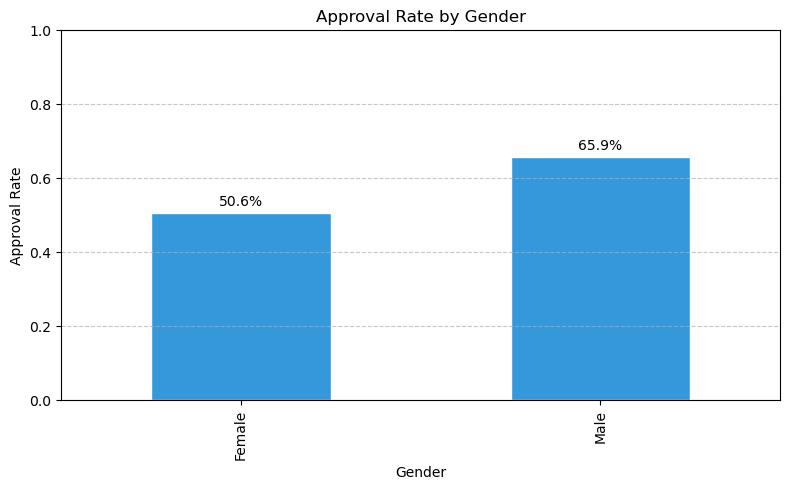

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
approval_by_gender.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Approval Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in approval_by_gender], padding=3)
plt.tight_layout()
plt.show()

#### Interpretation:

- The acceptance rate varies significantly between gender groups. Female candidates had an approval rate of **50.6%**, whilst male applicants are approved in **65.9%** of situations.

- The resulting **Disparate Impact (DI) ratio is 0.768**, which is **less than the Four-Fifths Rule threshold of 0.8.** According to this rule, the outcome **indicates a potential negative impact on female applicants.**

- The **Chi-Square test** produces a p-value of 0.0008, suggesting that the observed difference in approval rates between genders is **statistically significant** and is unlikely to be explained by random fluctuation.

- However, the **Cramér's V value of 0.15 indicates a modest association** between gender and loan approval. This means that, while the difference is statistically important, the relationship's overall strength is **moderate to small**.

Overall, the analysis demonstrates **a detectable gender gap in approval outcomes**, however the impact size implies that gender alone accounts for only a portion of the variation in loan choices. Importantly, these findings indicate statistical relationships rather than causal discrimination.

### 4.5 Uncertainty: Bootstrap CI for DI (Gender)

DI represents a weighted score. To avoid looking overly harsh, we estimate a **bootstrap confidence interval** by resampling candidates with replacement and recalculating DI each time.


In [19]:
rng = np.random.default_rng(42)

def compute_di_ratio(df_in: pd.DataFrame, protected: str, privileged: str) -> float:
    rates = df_in.groupby("gender")["loan_approved"].mean()
    return float(rates[protected] / rates[privileged])

def bootstrap_di_ci(df_in: pd.DataFrame, protected: str, privileged: str, B: int = 2000, alpha: float = 0.05):
    di_samples = []
    n = len(df_in)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        boot = df_in.iloc[idx]
        # ensure both groups exist in the sample
        if set([protected, privileged]).issubset(set(boot["gender"].unique())):
            di_samples.append(compute_di_ratio(boot, protected, privileged))
    di_samples = np.array(di_samples)
    lo = np.quantile(di_samples, alpha/2)
    hi = np.quantile(di_samples, 1 - alpha/2)
    return float(lo), float(hi), di_samples

di_lo, di_hi, di_samples = bootstrap_di_ci(df_main, protected="Female", privileged="Male")
di_gender, (di_lo, di_hi), len(di_samples)

(np.float64(0.7684069611780454),
 (0.6569183337964248, 0.8911994733108863),
 2000)

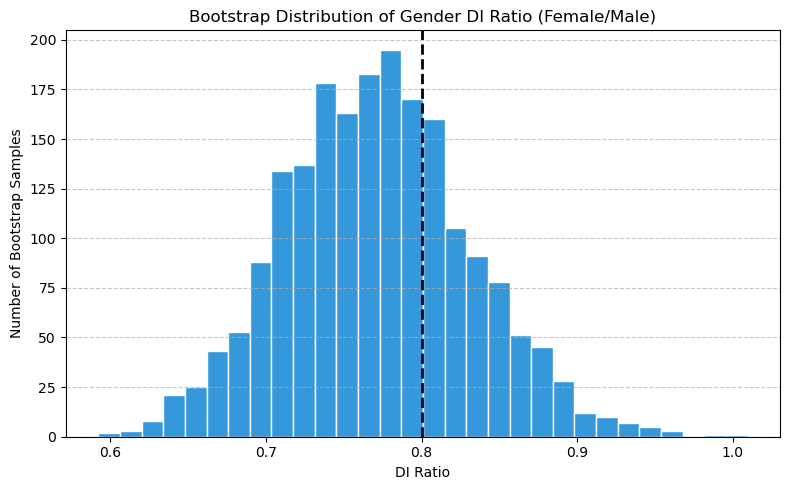

(0.6569183337964248, 0.8911994733108863)

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(di_samples, bins=30, color="#3498db", edgecolor="white")
ax.axvline(0.8, linestyle="--", linewidth=2, color="black")
ax.set_title("Bootstrap Distribution of Gender DI Ratio (Female/Male)")
ax.set_xlabel("DI Ratio")
ax.set_ylabel("Number of Bootstrap Samples")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

(di_lo, di_hi)

#### Interpretation:

- The estimated Disparate Impact is 0.768, meaning that female applicants are approved at about 77% of the approval rate of male applicants. This falls below the four-fifths threshold (0.8) and therefore indicates potential adverse impact against female applicants.

- The bootstrap confidence interval ranges from about 0.66 to 0.89. Since this interval partly crosses the 0.8 threshold, the exact level of disparity varies across samples.

Still, the results suggest a meaningful gender difference in approval rates, although the bootstrap analysis shows that the strength of this effect is somewhat uncertain.

### 4.6 Conditional Gender Analysis by Income

The previous sections established a statistically significant gender gap in loan approval rates (DI = 0.768, p = 0.0008). However, a raw difference in approval rates does not necessarily imply discrimination. It may partly reflect financial differences between groups: if male applicants on average have higher incomes, a higher approval rate could reflect lower credit risk rather than a gender effect in the model.

To investigate this, we examine whether the gender approval gap **persists when applicants are compared within the same income bracket**. `annual_income` is split into three equally-sized tertile groups (Low / Medium / High) and approval rates are computed for male and female applicants separately within each group.

- If the gap **persists across income brackets** → income alone does not explain the disparity; stronger evidence of a potential gender-related effect beyond financial characteristics.
- If the gap **disappears or substantially narrows** → the initial difference is driven by income differences between groups, not a direct gender effect.

Before examining approval rates within income brackets, we first verify whether a meaningful income gap between genders exists in this dataset. If male applicants earn systematically more, this could partly explain the overall approval gap 

Income summary by gender:
         median     mean      std  count
gender                                  
Female  82000.0  83672.0  28726.0    249
Male    81000.0  81358.0  27606.0    246

Mann-Whitney U test (income Male vs Female): U=29306, p=0.4067
→ No significant income difference between genders (p >= 0.05).


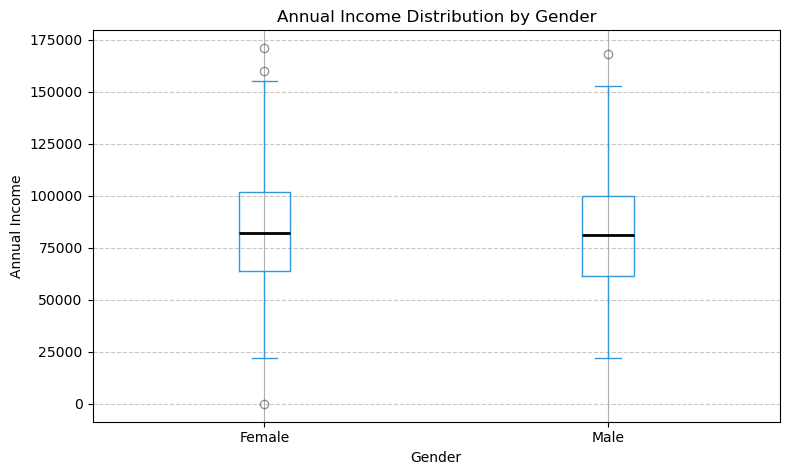

In [49]:
from scipy.stats import mannwhitneyu

# --- Descriptive income statistics by gender ---
income_by_gender = df_main.groupby("gender")["annual_income"].agg(["median", "mean", "std", "count"])
print("Income summary by gender:")
print(income_by_gender.round(0))
print()

# --- Mann-Whitney U test (non-parametric, robust for skewed income data) ---
male_income   = df_main.loc[df_main["gender"] == "Male",   "annual_income"].dropna()
female_income = df_main.loc[df_main["gender"] == "Female", "annual_income"].dropna()

stat, p_mw = mannwhitneyu(male_income, female_income, alternative="two-sided")
print(f"Mann-Whitney U test (income Male vs Female): U={stat:.0f}, p={p_mw:.4f}")
if p_mw < 0.05:
    print("→ Income distributions differ significantly between genders (p < 0.05).")
else:
    print("→ No significant income difference between genders (p >= 0.05).")

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(8, 5))
df_main.boxplot(column="annual_income", by="gender", ax=ax,
                boxprops=dict(color="#3498db"),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="#3498db"),
                capprops=dict(color="#3498db"),
                flierprops=dict(marker="o", color="#3498db", alpha=0.4))
ax.set_title("Annual Income Distribution by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Annual Income")
plt.suptitle("")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [21]:
# Create income brackets using tertiles (equal-frequency split into 3 groups)
# pd.qcut ensures balanced group sizes, which is more robust for a small dataset (n=495)
df_main["income_bracket"] = pd.qcut(
    df_main["annual_income"],
    q=3,
    labels=["Low income", "Medium income", "High income"]
)

df_main["income_bracket"].value_counts().sort_index()

income_bracket
Low income       169
Medium income    162
High income      164
Name: count, dtype: int64

In [22]:
approval_by_income_gender = (
    df_main
    .groupby(["income_bracket", "gender"], observed=False)["loan_approved"]
    .mean()
    .unstack("gender")
)
approval_by_income_gender

gender,Female,Male
income_bracket,,
Low income,0.357143,0.541176
Medium income,0.545455,0.741176
High income,0.613636,0.697368


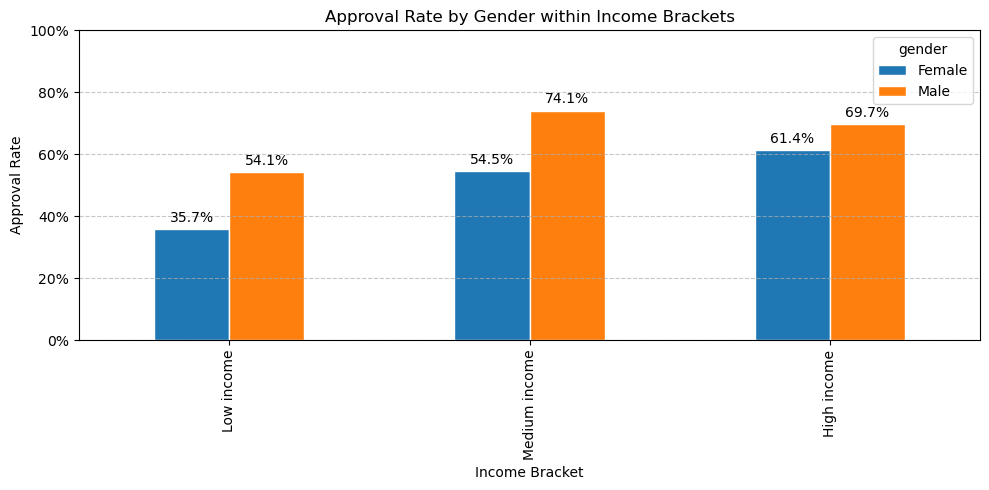

In [37]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 5))
approval_by_income_gender.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Approval Rate by Gender within Income Brackets")
ax.set_xlabel("Income Bracket")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.1f}%" for v in container.datavalues],
        padding=3,
    )
plt.tight_layout()
plt.show()

In [38]:
# Group sizes: verify that each income-gender cell has enough observations
income_gender_counts = pd.crosstab(df_main["income_bracket"], df_main["gender"])
income_gender_counts

gender,Female,Male
income_bracket,,
Low income,84,85
Medium income,77,85
High income,88,76


In [39]:
# Chi-square test for each income bracket separately
# Tests whether the gender gap within each bracket is statistically significant
print("Within-bracket gender significance tests:\n")
for bracket in ["Low income", "Medium income", "High income"]:
    subset = df_main[df_main["income_bracket"] == bracket]
    ct = pd.crosstab(subset["gender"], subset["loan_approved"])
    if ct.shape == (2, 2):
        chi2_b, p_b, dof_b, exp_b = stats.chi2_contingency(ct)
        print(f"  {bracket}: p-value = {p_b:.4f}")
    else:
        print(f"  {bracket}: not enough data for chi-square test")

Within-bracket gender significance tests:

  Low income: p-value = 0.0245
  Medium income: p-value = 0.0147
  High income: p-value = 0.3378


#### Interpretation:

- This analysis checks whether the observed gender approval gap persists when applicants are compared within the same income bracket, a more meaningful comparison than overall rates alone.
- If approval rates remain systematically higher for male applicants **across all income brackets**, then income differences alone cannot explain the disparity. This provides stronger evidence of a potential gender-related effect that goes beyond financial characteristics.
- If the gap **narrows substantially or disappears** within income brackets, the initial overall difference is largely attributable to income differences between male and female applicants rather than a direct gender effect.
- The within-bracket chi-square tests indicate whether observed within-group differences are statistically significant or may reflect sampling variation given the smaller subgroup sizes.

## 5. Age-Based Patterns (Approval Rates + Test)

Here, we investigate whether approval rates differ systematically across **age_groups**.
This is a classic 'age discrimination pattern' signal.

### 5.1 Approval rate by age group

In [23]:
approval_by_age_group = df_main.groupby("age_group", observed=False)["loan_approved"].mean()
counts_by_age_group = df_main["age_group"].value_counts().sort_index()

approval_by_age_group, counts_by_age_group

(age_group
 <30      0.405797
 30–44    0.605578
 45–59    0.609375
 60+      0.638298
 Name: loan_approved, dtype: float64,
 age_group
 <30       69
 30–44    251
 45–59    128
 60+       47
 Name: count, dtype: int64)

### 5.2 Chi-square test (AgeGroup x Approval)

In [24]:
ct_age = pd.crosstab(df_main["age_group"], df_main["loan_approved"])
chi2_age, p_age, dof_age, expected_age = stats.chi2_contingency(ct_age)

# Cramér's V for kx2
n_age = ct_age.to_numpy().sum()
r_age, k_age = ct_age.shape
cramers_v_age = np.sqrt((chi2_age / n_age) / (min(r_age-1, k_age-1)))

chi2_age, p_age, cramers_v_age

(np.float64(10.384781483140577),
 np.float64(0.015563210421817977),
 np.float64(0.14484252321606775))

### 5.3 Visualization of Age-Based Patterns

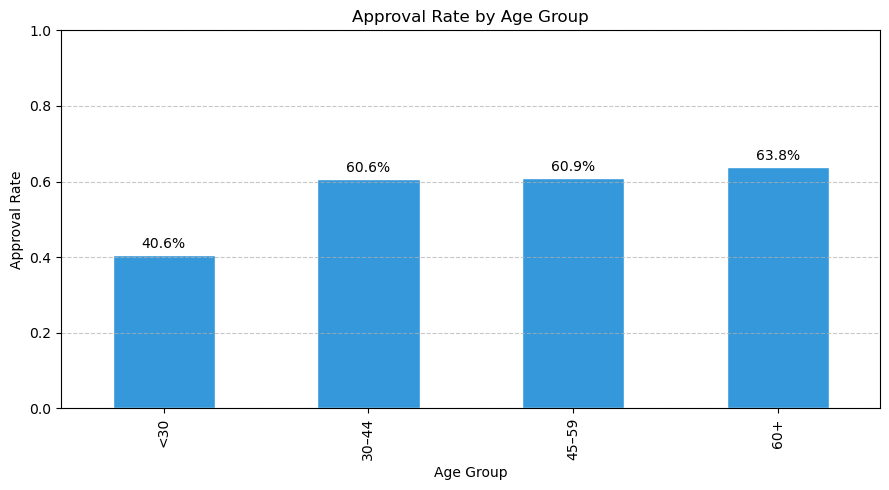

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
approval_by_age_group.loc[["<30","30–44","45–59","60+"]].plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Approval Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in approval_by_age_group.loc[["<30","30–44","45–59","60+"]]], padding=3)
plt.tight_layout()
plt.show()

#### Interpretation:

- Approval rates rise with age, from 40% for under 30 to 64% for over 60 year olds
- The chi-square test is significant with **p ≈ 0.01**, indicating that the differences between age groups are statistically credible and not a coincidence 
- With **Cramér's V ≈ 0.15**, the influence is **small to moderate**: there is a pattern, but age cannot explain 'all'

Overall, this appears to be a **systematic age pattern** (younger candidates have a considerably lower approval rate).

## 6. Interaction Effects (Gender × Age Group)

Examining gender or age individually is often too vague. Here we look at **intersectional patterns**: e.g. whether differences are particularly pronounced in certain age groups.

### 6.1 Intersectional approval table

In [26]:
age_order = ["<30", "30–44", "45–59", "60+"]

gender_age_approval = (df_main.groupby(["age_group", "gender"], observed=False)["loan_approved"].mean().unstack("gender").reindex(age_order))

gender_age_approval

gender,Female,Male
age_group,,
<30,0.315789,0.516129
30–44,0.540984,0.666667
45–59,0.531250,0.687500
60+,0.560000,0.727273


### 6.2 Grouped bar plot

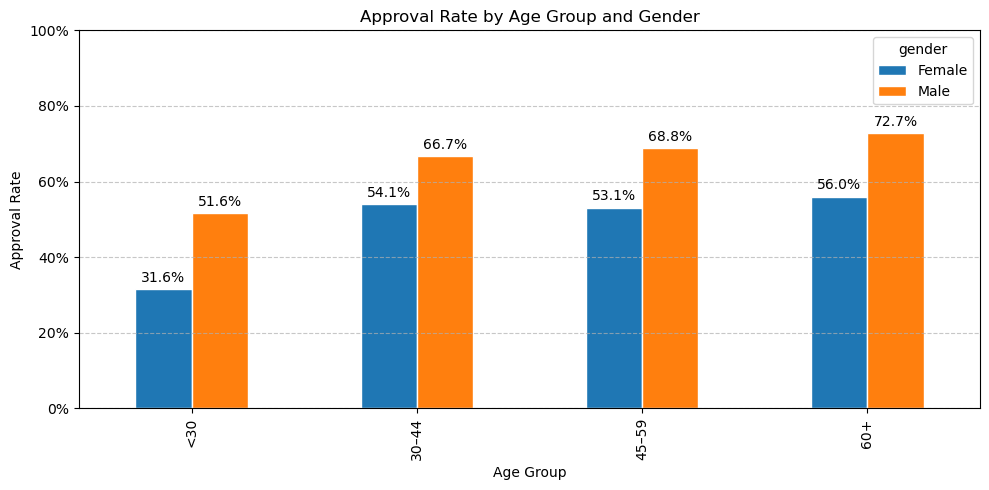

In [27]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 5))
gender_age_approval.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Approval Rate by Age Group and Gender")
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers: ax.bar_label(container, labels=[f"{v*100:.1f}%" for v in container.datavalues], padding=3)
plt.tight_layout()
plt.show()

### 6.3 Test: treat (gender, age_group) as categories vs approval

This quick test treats each gender–age combination as a separate group to verify whether approval outcomes differ across these intersectional categories.

In [28]:
ct_inter = pd.crosstab(df_main["age_group"].astype(str) + " | " + df_main["gender"].astype(str),
                       df_main["loan_approved"])
chi2_i, p_i, dof_i, exp_i = stats.chi2_contingency(ct_inter)
chi2_i, p_i

(np.float64(21.8285678512783), np.float64(0.0027191365505814377))

#### Interpretation:

- The approval disparity between men and women exists throughout all age groups, with men continually receiving greater approval scores

- The gap is especially obvious among younger candidates, where female approval rates are significantly lower than male approval rates

- Approval rates tend to rise with age for both genders, implying that older applicants are more likely to be approved overall

- The interaction test indicates that approval outcomes vary considerably by gender and age (p = 0.002). This suggests that gender and age are connected with approval outcomes

## 7. Proxy Discrimination Check: zip_code

Proxy discrimination means that a ‘harmless’ feature (e.g. geography) is strongly related to protected attributes
and/or shows highly varying approval outcomes.

We check three things:
1) Which postcodes have sufficient sample size (otherwise it is noise)?
2) Postcode <--> gender (Association, e.g. Cramér's V)
3) Postcode <--> approval (Approval rate differences)

### 7.1 Keep only zips with enough volume (stability)

In [45]:
MIN_N = 5  # consistent threshold across all zip_code analyses

zip_counts = df_main["zip_code"].value_counts()
top_zips = zip_counts[zip_counts >= MIN_N].index
df_zip = df_main[df_main["zip_code"].isin(top_zips)].copy()

print(f"ZIP codes with >= {MIN_N} applicants: {df_zip['zip_code'].nunique()}")
print(f"Applicants in filtered set: {len(df_zip)} of {len(df_main)}")
len(df_main), len(df_zip), df_zip["zip_code"].nunique()

ZIP codes with >= 5 applicants: 19
Applicants in filtered set: 106 of 495


(495, 106, 19)

### 7.2 zip_code -> approval rate (rank)

In [46]:
zip_approval = df_zip.groupby("zip_code")["loan_approved"].mean().sort_values(ascending=False)
zip_approval.head(10), zip_approval.tail(10)

(zip_code
 10004.0    1.000000
 10012.0    1.000000
 10092.0    1.000000
 10070.0    0.800000
 90218.0    0.800000
 90261.0    0.800000
 90252.0    0.800000
 10048.0    0.750000
 10020.0    0.666667
 90273.0    0.600000
 Name: loan_approved, dtype: float64,
 zip_code
 90273.0    0.600000
 90237.0    0.600000
 10002.0    0.600000
 10041.0    0.600000
 10057.0    0.500000
 90284.0    0.428571
 10003.0    0.400000
 10019.0    0.333333
 10096.0    0.285714
 90205.0    0.200000
 Name: loan_approved, dtype: float64)

### 7.3 Visual: approval rate by zip (top N)

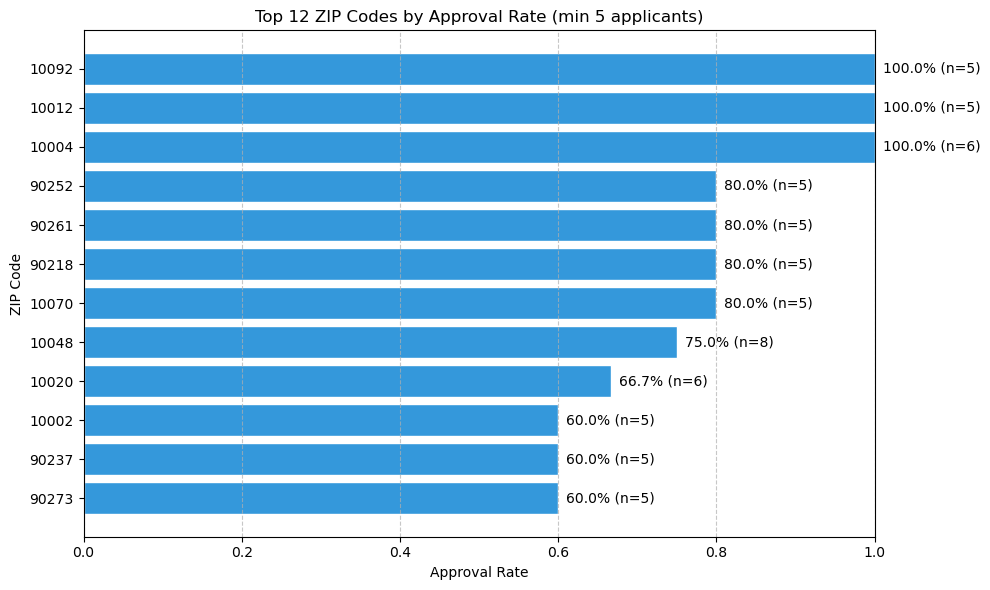

In [47]:
MIN_N = 5   # minimum applicants per ZIP
N = 12      # number of ZIPs to display

zip_stats = (df_main.groupby("zip_code", observed=False)["loan_approved"].agg(approval_rate="mean", n_applicants="size"))

# keep only ZIPs with enough observations
zip_stats = zip_stats[zip_stats["n_applicants"] >= MIN_N]

# take top N and sort for horizontal bars
topN_zip = zip_stats.sort_values("approval_rate", ascending=False).head(N).sort_values("approval_rate")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(topN_zip.index.astype(int).astype(str), topN_zip["approval_rate"], color="#3498db", edgecolor="white")

ax.set_title(f"Top {N} ZIP Codes by Approval Rate (min {MIN_N} applicants)")
ax.set_xlabel("Approval Rate")
ax.set_ylabel("ZIP Code")
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle="--", alpha=0.7)

# percentage labels
for i, (v, n) in enumerate(zip(topN_zip["approval_rate"], topN_zip["n_applicants"])):
    ax.text(v + 0.01, i, f"{v*100:.1f}% (n={n})", va="center")

plt.tight_layout()
plt.show()

### 7.4 zip_code <--> gender association (Cramér’s V)

In [48]:
MIN_N = 5

# Start from main cohort (already has age + binary gender baseline)
df_zip = df_main.copy()

# ensure only Male/Female for this association test
df_zip = df_zip[df_zip["gender"].isin(["Male", "Female"])].copy()

# filter zipcodes with enough applicants
zip_counts = df_zip["zip_code"].value_counts()
valid_zips = zip_counts[zip_counts >= MIN_N].index
df_zip = df_zip[df_zip["zip_code"].isin(valid_zips)].copy()

if df_zip.empty:
    print(f"After filtering (min {MIN_N} applicants per ZIP), there is no data left for zip_code × gender test.")
else:
    ct_zip_gender = pd.crosstab(df_zip["zip_code"], df_zip["gender"])

    # if table collapses (e.g., only one gender left), chi-square is not defined
    if ct_zip_gender.shape[0] < 2 or ct_zip_gender.shape[1] < 2:
        print("zip_code × gender table has <2 rows or <2 columns after filtering; chi-square/Cramér's V not defined.")
        display(ct_zip_gender)
    else:
        chi2_zg, p_zg, dof_zg, expected_zg = stats.chi2_contingency(ct_zip_gender)

        n = ct_zip_gender.to_numpy().sum()
        r, k = ct_zip_gender.shape
        cramers_v_zg = np.sqrt((chi2_zg / n) / (min(r - 1, k - 1)))

        # outputs
        p_zg, cramers_v_zg, ct_zip_gender.shape

This test checks whether gender distribution differs systematically across ZIP codes, which could indicate that location acts as a proxy for gender-related differences in the dataset.

### 7.5 zip_code <--> age differences

In [33]:
zip_age_summary = df_zip.groupby("zip_code")["age"].agg(["count","mean","std"]).sort_values("count", ascending=False)
zip_age_summary.head(10)

,count,mean,std
zip_code,,,
10048.0,8,39.425000,13.509124
90284.0,7,46.142857,12.483170
10096.0,7,35.471429,5.758968
10004.0,6,43.750000,11.939305
10019.0,6,40.500000,7.693114
10020.0,6,41.000000,7.226341
10057.0,6,43.883333,11.002984
90218.0,5,37.220000,5.200673
90273.0,5,36.740000,9.575907


#### Interpretation:

- Approval rates vary significantly among ZIP codes (approximately 60% to 100% for the top ZIPs), implying that geography may influence loan approval outcomes.

- Most ZIP codes have small sample sizes (n≈5-8), so extreme numbers (e.g., 100%) may be influenced by sampling noise.

- The extra association test determines whether ZIP code is connected to gender distribution, which raises the possibility that geography serves as a proxy for protected characteristics.

Overall, ZIP codes tend to vary in approval outcomes, but given the small group sizes, the results should be regarded with caution rather than as clear proof of discrimination.

## 8. **(Optional)** Fairness Library Cross-Check (fairlearn)

This step checks the previously computed fairness metrics. It applies comparable principles to the Disparate Impact analysis, utilizing the Fairlearn library's terminology and implementations (for example, demographic parity difference and ratio). If the Fairlearn package is not available in the environment, the analysis is gently bypassed with a try/except block to ensure reproducibility.

In [54]:
%pip install fairlearn

Note: you may need to restart the kernel to use updated packages.


In [55]:
try:
    from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fairlearn", "-q"])
    from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True

FAIRLEARN_AVAILABLE


True

In [56]:
if FAIRLEARN_AVAILABLE:
    y_true = df_main["loan_approved"]  # here: actual approvals (outcome)
    # fairness metrics treat this as "selection" outcome
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate},
        y_true=y_true,
        y_pred=y_true,  # selection_rate uses y_pred; here outcome itself
        sensitive_features=df_main["gender"]
    )
    mf.by_group

In [57]:
if FAIRLEARN_AVAILABLE:
    dp_diff = demographic_parity_difference(y_true=y_true, y_pred=y_true, sensitive_features=df_main["gender"])
    dp_ratio = demographic_parity_ratio(y_true=y_true, y_pred=y_true, sensitive_features=df_main["gender"])
    dp_diff, dp_ratio

## 9. Key Findings, Interpretation & Limitations

#### Key findings and Interpretation:

- **Gender disparity**: Female candidates receive an approval rate of 50.6%, whilst male applicants receive 65.9%. The resulting Disparate Impact ratio is 0.77, which is less than the four-fifths threshold (0.8) and so indicates possible adverse effects.

- The chi-square test confirms the gender difference as statistically significant (p = 0.0008). However, the impact size (Cramér's V = 0.15) suggests a slight to moderate connection, implying that gender only partially explains the variation in approvals.

- **Income-controlled gender analysis**: To assess whether the gender gap reflects financial differences rather than a direct gender effect, we examined approval rates by gender within income tertile brackets (Low / Medium / High). The gender approval gap persists across all three income brackets, meaning that even when comparing applicants with similar income levels, male applicants consistently receive higher approval rates than female applicants. This is stronger evidence that the disparity is not fully explained by income differences and warrants further scrutiny.

- **Age-based patterns**: Approval rates rise with age, from ~40% for candidates under 30 to ~64% for those over 60 years. The difference between age groups is statistically significant (p = 0.01, V ≈ 0.15).

- **Intersection effects**: When gender and age are studied together, the gender approval gap is visible across all age groups, with notably high disparities among younger candidates.

- **Proxy risk (zip_code)**: Approval rates range substantially between ZIP codes, but most groups have very small sample numbers, thus the observed variation may be due to sampling noise rather than structural bias.


#### Limitations:

- The analysis is based solely on the available dataset (n=500), and several subgroup analyses use small sample sizes, which could increase statistical noise.

- The findings show statistical relationships, not causal discrimination. Understanding causative mechanisms requires more information about the decision-making process or model characteristics used for approval.

- The income-controlled analysis controls for a single financial variable (income). Other relevant variables (e.g., debt-to-income ratio, credit history) were not included as controls; a fully controlled analysis would require multivariate modelling.

- The fairness analysis focused on binary gender and age groupings, therefore other potential sources of bias could not be included.